# View CoTransmission Patterns

In [1]:
# libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Create nt_results_df by loading csvs into single dataframe

In [2]:
# Get list of all csv files with `nt_results_*.csv`
csv_files = [f for f in os.listdir() if f.startswith('nt_results_') and f.endswith('.csv')]
print(csv_files)

['nt_results_cell-type_DNg8.*.csv', 'nt_results_cell-type_efferent_range_400_500.csv', 'nt_results_cell-type_efferent_range_1000_1100.csv', 'nt_results_cell-type_afferent_range_500_600.csv', 'nt_results_cell-type_afferent_range_4200_4300.csv', 'nt_results_cell-type_afferent_range_2500_2600.csv', 'nt_results_cell-type_afferent_range_200_300.csv', 'nt_results_cell-type_afferent_range_2900_3000.csv', 'nt_results_cell-type_afferent_range_400_500.csv', 'nt_results_cell-type_DNx.*.csv', 'nt_results_cell-type_efferent_range_500_600.csv', 'nt_results_cell-type_DNp5.*.csv', 'nt_results_cell-type_efferent_range_200_300.csv', 'nt_results_cell-type_DNc.*.csv', 'nt_results_cell-type_DNp7.*.csv', 'nt_results_cell-type_DNa.*.csv', 'nt_results_cell-type_AN_range_1300_1400.csv', 'nt_results_cell-type_afferent_range_1300_1400.csv', 'nt_results_cell-type_afferent_range_4500_4600.csv', 'nt_results_cell-type_afferent_range_2200_2300.csv', 'nt_results_cell-type_mechanosensory_range_300_400.csv', 'nt_results

In [3]:
# Load csvs into single dataframe
nt_results_df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
nt_results_df.head()

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA,ACh,Glut,Oct,Ser,DA,Unknown
0,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.142857,0.01,False,True,False,False,True,True,False
1,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.040000,0.01,False,True,False,False,True,False,False
2,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.142857,0.01,False,True,True,True,True,True,False
3,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.040000,0.01,False,True,False,False,True,True,False
4,720575940639152361,cell_type,DNg84,6617,400,0.25,0.16,0.142857,0.01,True,True,True,True,True,True,False


### Create metrics

In [6]:
## Create the num_nts, and is_co_transmission columns
nts = ["GABA", "ACh", "Glut", "Oct", "Ser", "DA"]
#num nts = sum of ["GABA", "ACh", "Glut", "Oct", "Ser", "DA"]
nt_results_df['num_nts'] = nt_results_df[nts].sum(axis=1)
nt_results_df['is_co_transmission'] = nt_results_df['num_nts'] > 1

nt_results_df.head()


,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA,ACh,Glut,Oct,Ser,DA,Unknown,num_nts,is_co_transmission
0,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.142857,0.01,False,True,False,False,True,True,False,3,True
1,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.040000,0.01,False,True,False,False,True,False,False,2,True
2,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.142857,0.01,False,True,True,True,True,True,False,5,True
3,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.040000,0.01,False,True,False,False,True,True,False,3,True
4,720575940639152361,cell_type,DNg84,6617,400,0.25,0.16,0.142857,0.01,True,True,True,True,True,True,False,6,True


## Overall statistics

### Descriptive Statistics

,root_id,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,num_nts
count,1.636480e+05,163648.000000,163648.0,163648.00,1.636480e+05,163648.000000,1.636480e+05,163648.000000
mean,7.205759e+17,2543.523318,400.0,0.25,1.600000e-01,0.091429,1.000000e-02,3.414121
std,1.026184e+07,3991.289918,0.0,0.00,2.775566e-17,0.051429,1.734729e-18,1.312788
min,7.205759e+17,401.000000,400.0,0.25,1.600000e-01,0.040000,1.000000e-02,1.000000
25%,7.205759e+17,667.000000,400.0,0.25,1.600000e-01,0.040000,1.000000e-02,3.000000
50%,7.205759e+17,1202.000000,400.0,0.25,1.600000e-01,0.091429,1.000000e-02,3.000000
75%,7.205759e+17,2976.000000,400.0,0.25,1.600000e-01,0.142857,1.000000e-02,4.000000
max,7.205759e+17,95361.000000,400.0,0.25,1.600000e-01,0.142857,1.000000e-02,6.000000


Number of rows in the DataFrame: 163648


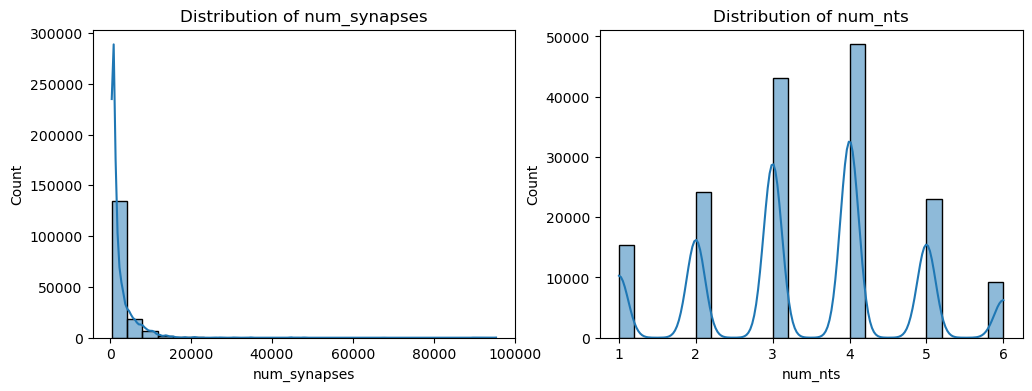

In [20]:
display(nt_results_df.describe())
print(f"Number of rows in the DataFrame: {nt_results_df.shape[0]}")

quant_cols = ['num_synapses', 'num_nts']
# Plot data spread
fig, ax = plt.subplots(1, len(quant_cols), figsize=(6 * len(quant_cols), 4))
for i, col in enumerate(quant_cols):
    sns.histplot(data=nt_results_df, x=col, bins=25, kde=True, ax=ax[i])
    ax[i].set_title(f'Distribution of {col}')

root_id
720575940635668622    68
720575940604926082    68
720575940632834911    68
720575940633387768    68
720575940614997555    68
                      ..
720575940611430117     2
720575940629151031     2
720575940615146562     2
720575940620912086     2
720575940630171959     2
Name: count, Length: 5892, dtype: int64

Text(0, 0.5, 'Frequency')

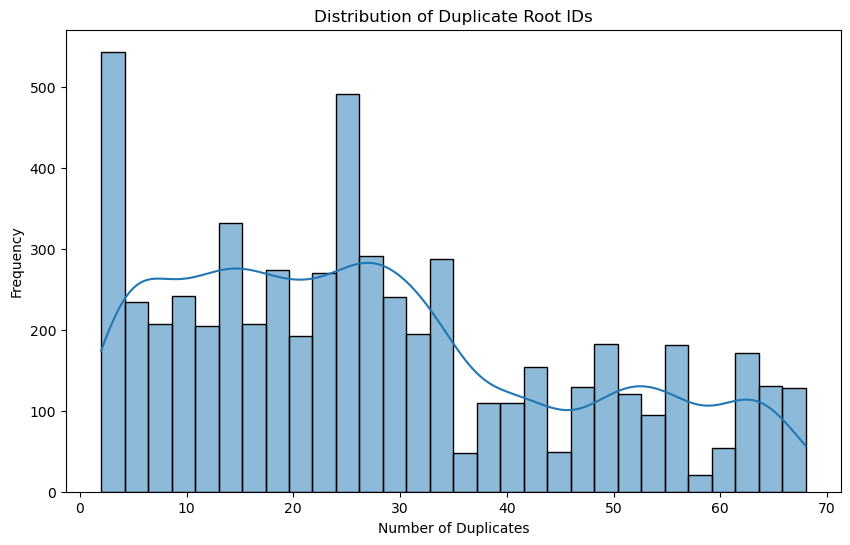

In [21]:
# Amount of duplication
duplicate_root_ids = nt_results_df["root_id"].value_counts()
display(duplicate_root_ids)
plt.figure(figsize=(10, 6))
sns.histplot(duplicate_root_ids, kde=True, bins=30)
plt.title("Distribution of Duplicate Root IDs")
plt.xlabel("Number of Duplicates")
plt.ylabel("Frequency")

### How different are the duplicates?

In [33]:

# duplicated_root_ids = nt_results_df.groupby("root_id")[nts + ['num_nts']].agg(np.mean(), np.std, np.min, np.max)
# display(duplicated_root_ids)
# nt_results_by_root_id = nt_results_df.pivot_table(index="root_id", values=nts + ['num_nts'], aggfunc=['mean', 'std', 'min', 'max'])
nt_results_by_root_id = nt_results_df.pivot_table(index=["root_id", "classification_system", "cell_type"], values=['num_synapses'] + nts + ['num_nts'], aggfunc=['mean', 'std', 'min', 'max'])
nt_results_by_root_id.head(50)

mean                 \
                                                         ACh   DA GABA Glut   
root_id            classification_system cell_type                            
720575940600433181 cell_class            mechanosensory  1.0  0.0  1.0  0.0   
                   flow                  afferent        1.0  0.0  1.0  0.0   
720575940600646173 cell_class            mechanosensory  1.0  0.0  1.0  1.0   
                   flow                  afferent        1.0  0.0  1.0  1.0   
720575940602132509 cell_class            mechanosensory  1.0  0.0  0.5  0.5   
                   flow                  afferent        1.0  0.0  0.5  0.5   
720575940602337504 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940602353632 cell_class            gustatory       1.0  1.0  0.5  0.0   
                   flow                  afferent        1.0  1.0  0.5  0.0   
720575940602382304 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940602430944 cell_class            AN              1.0  0.5  0.0  0.0   
                   flow                  afferent        1.0  0.5  0.0  0.0   
720575940602444512 cell_class            AN              1.0  1.0  1.0  1.0   
                   flow                  afferent        1.0  1.0  1.0  1.0   
720575940602506208 cell_class            mechanosensory  1.0  0.0  1.0  0.0   
                   flow                  afferent        1.0  0.0  1.0  0.0   
720575940602703072 cell_class            AN              1.0  1.0  0.0  1.0   
                   flow                  afferent        1.0  1.0  0.0  1.0   
720575940602893228 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940603266592 cell_class            gustatory       1.0  1.0  0.0  1.0   
                   flow                  afferent        1.0  1.0  0.0  1.0   
720575940603356128 flow                  afferent        1.0  1.0  0.0  0.0   
720575940603453542 cell_class            AN              1.0  1.0  1.0  0.0   
                   flow                  afferent        1.0  1.0  1.0  0.0   
720575940603456288 cell_class            AN              1.0  0.5  0.0  0.0   
                   flow                  afferent        1.0  0.5  0.0  0.0   
720575940603460640 cell_class            AN              1.0  0.0  0.5  0.5   
                   flow                  afferent        1.0  0.0  0.5  0.5   
720575940603461478 cell_class            AN              1.0  0.0  1.0  1.0   
                   flow                  afferent        1.0  0.0  1.0  1.0   
720575940603479910 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940603537766 cell_class            AN              1.0  1.0  1.0  1.0   
                   flow                  afferent        1.0  1.0  1.0  1.0   
720575940603545190 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940603574374 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940603591014 cell_type             DNae006         1.0  0.5  1.0  0.5   
                   flow                  efferent        1.0  0.5  1.0  0.5   
720575940603595366 cell_class            AN              1.0  0.0  0.5  0.0   
                   flow                  afferent        1.0  0.0  0.5  0.0   
720575940603599206 cell_class            AN              1.0  0.0  0.0  0.0   
                   flow                  afferent        1.0  0.0  0.0  0.0   
720575940603600230 cell_class            AN              1.0  0.0  0.0  0.5   
                   flow    

In [39]:
# Show detailed rows for duplicated root_ids and a compact summary of differences
cols = ['root_id', 'classification_system', 'cell_type', 'num_synapses'] + nts + ['num_nts']

# detailed rows (all entries that share a root_id)
dup_df = nt_results_df[nt_results_df['root_id'].duplicated(keep=False)][cols].sort_values(['root_id', 'num_synapses'])
display(dup_df)

# Summary: for each duplicated root_id list unique values and count unique values (nunique)
agg_kwargs = {}
# add the number of duplicates
agg_kwargs['num_duplicates'] = ('root_id', 'count')

for c in cols[3:]:
    agg_kwargs[f'{c}_unique'] = (c, lambda s, c=c: list(s.unique()))
    agg_kwargs[f'{c}_nunique'] = (c, 'nunique')

print(f"agg_kwargs: {agg_kwargs}")
summary = dup_df.groupby('root_id').agg(**agg_kwargs)

# add flag if any column differs across duplicates
nunique_cols = [c for c in summary.columns if c.endswith('_nunique')]
summary['any_difference'] = (summary[nunique_cols] > 1).any(axis=1)

# show root_ids with differences first
display(summary.sort_values('num_duplicates', ascending=False))

,root_id,classification_system,cell_type,num_synapses,GABA,ACh,Glut,Oct,Ser,DA,num_nts
3998,720575940600433181,flow,afferent,763,True,True,False,False,False,False,2
3999,720575940600433181,flow,afferent,763,True,True,False,False,False,False,2
19774,720575940600433181,flow,afferent,763,True,True,False,False,False,False,2
19775,720575940600433181,flow,afferent,763,True,True,False,False,False,False,2
44860,720575940600433181,cell_class,mechanosensory,763,True,True,False,False,False,False,2
...,...,...,...,...,...,...,...,...,...,...,...
73775,720575940661338497,flow,efferent,1244,True,True,True,True,True,True,6
106944,720575940661338497,flow,efferent,1244,True,True,True,True,True,True,6
106945,720575940661338497,flow,efferent,1244,True,True,True,True,True,True,6
158714,720575940661338497,flow,efferent,1244,True,True,True,True,True,True,6


agg_kwargs: {'num_duplicates': ('root_id', 'count'), 'num_synapses_unique': ('num_synapses', <function <lambda> at 0x17b69e7a0>), 'num_synapses_nunique': ('num_synapses', 'nunique'), 'GABA_unique': ('GABA', <function <lambda> at 0x17b69fa60>), 'GABA_nunique': ('GABA', 'nunique'), 'ACh_unique': ('ACh', <function <lambda> at 0x17901bf60>), 'ACh_nunique': ('ACh', 'nunique'), 'Glut_unique': ('Glut', <function <lambda> at 0x17901bce0>), 'Glut_nunique': ('Glut', 'nunique'), 'Oct_unique': ('Oct', <function <lambda> at 0x17901a840>), 'Oct_nunique': ('Oct', 'nunique'), 'Ser_unique': ('Ser', <function <lambda> at 0x17b59bd80>), 'Ser_nunique': ('Ser', 'nunique'), 'DA_unique': ('DA', <function <lambda> at 0x17bb17ba0>), 'DA_nunique': ('DA', 'nunique'), 'num_nts_unique': ('num_nts', <function <lambda> at 0x17bb17240>), 'num_nts_nunique': ('num_nts', 'nunique')}


,num_duplicates,num_synapses_unique,num_synapses_nunique,GABA_unique,GABA_nunique,ACh_unique,ACh_nunique,Glut_unique,Glut_nunique,Oct_unique,Oct_nunique,Ser_unique,Ser_nunique,DA_unique,DA_nunique,num_nts_unique,num_nts_nunique,any_difference
root_id,,,,,,,,,,,,,,,,,,
720575940628337511,68,[2488],1,"[True, False]",2,[True],1,[True],1,[True],1,[True],1,[False],1,"[5, 4]",2,True
720575940634725345,68,[1604],1,[True],1,[True],1,[True],1,[False],1,[False],1,[True],1,[4],1,False
720575940637106295,68,[1701],1,[True],1,[True],1,[True],1,"[True, False]",2,[True],1,"[True, False]",2,"[6, 4]",2,True
720575940633183559,68,[1292],1,[False],1,[True],1,"[True, False]",2,[False],1,[False],1,[False],1,"[2, 1]",2,True
720575940633387768,68,[1282],1,[True],1,[True],1,[True],1,[False],1,[True],1,[False],1,[4],1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
720575940636809950,2,[457],1,"[True, False]",2,[True],1,[False],1,[False],1,[True],1,[True],1,"[4, 3]",2,True
720575940628264721,2,[2578],1,[True],1,[True],1,"[True, False]",2,[False],1,"[True, False]",2,[False],1,"[4, 2]",2,True
720575940639080526,2,[693],1,"[True, False]",2,[True],1,[False],1,[False],1,[True],1,[True],1,"[4, 3]",2,True


In [41]:
nt_results_df[nt_results_df['root_id'] == 720575940628337511][['classification_system', 'cell_type', 'num_synapses']].value_counts()

classification_system  cell_type  num_synapses
flow                   afferent   2488            66
cell_class             AN         2488             2
Name: count, dtype: int64

In [42]:
nt_results_df[nt_results_df['root_id'] == 720575940628337511][nts + ['num_nts']].value_counts()

GABA   ACh   Glut  Oct   Ser   DA     num_nts
False  True  True  True  True  False  4          34
True   True  True  True  True  False  5          34
Name: count, dtype: int64

Ok there seem to be a lot of duplicated values with the same root_id. We need to drop the duplicates

In [43]:
filt_nt_results_df = nt_results_df.drop_duplicates()
filt_nt_results_df

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA,ACh,Glut,Oct,Ser,DA,Unknown,num_nts,is_co_transmission
0,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.142857,0.01,False,True,False,False,True,True,False,3,True
1,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.040000,0.01,False,True,False,False,True,False,False,2,True
2,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.142857,0.01,False,True,True,True,True,True,False,5,True
3,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.040000,0.01,False,True,False,False,True,True,False,3,True
4,720575940639152361,cell_type,DNg84,6617,400,0.25,0.16,0.142857,0.01,True,True,True,True,True,True,False,6,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163643,720575940622486644,cell_type,DNg45,754,400,0.25,0.16,0.040000,0.01,True,True,True,True,True,True,False,6,True
163644,720575940622037926,cell_type,DNg41,3238,400,0.25,0.16,0.142857,0.01,True,True,True,False,True,False,False,4,True
163645,720575940622037926,cell_type,DNg41,3238,400,0.25,0.16,0.040000,0.01,True,True,True,False,True,False,False,4,True
163646,720575940636329579,cell_type,DNg41,3442,400,0.25,0.16,0.142857,0.01,True,True,True,False,True,True,False,5,True


In [45]:
# Now split accordinging to threshold combinations
softmax_thresholds = filt_nt_results_df['softmax_threshold'].unique()
print(f"Softmax_thresholds: {softmax_thresholds}")
ratio_thresholds = filt_nt_results_df['ratio_threshold'].unique()
print(f"Ratio_thresholds: {ratio_thresholds}")
bandwidth_thresholds = filt_nt_results_df['bandwidth_quantile_value'].unique()
print(f"Bandwidth_thresholds: {bandwidth_thresholds}")

Softmax_thresholds: [0.25]
Ratio_thresholds: [0.16]
Bandwidth_thresholds: [0.14285714 0.04      ]


In [46]:
# So now create two different filtered DataFrames based on the threshold combinations
filt_nt_results_df_high = filt_nt_results_df[(filt_nt_results_df['bandwidth_quantile_value'] == bandwidth_thresholds[0])]
filt_nt_results_df_low = filt_nt_results_df[(filt_nt_results_df['bandwidth_quantile_value'] == bandwidth_thresholds[1])]

print(f"Number of rows in the high bandwidth filtered DataFrame: {filt_nt_results_df_high.shape[0]}")
display(filt_nt_results_df_high.head())

print(f"Number of rows in the low bandwidth filtered DataFrame: {filt_nt_results_df_low.shape[0]}")
display(filt_nt_results_df_low.head())

Number of rows in the high bandwidth filtered DataFrame: 9529


,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA,ACh,Glut,Oct,Ser,DA,Unknown,num_nts,is_co_transmission
0,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.142857,0.01,False,True,False,False,True,True,False,3,True
2,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.142857,0.01,False,True,True,True,True,True,False,5,True
4,720575940639152361,cell_type,DNg84,6617,400,0.25,0.16,0.142857,0.01,True,True,True,True,True,True,False,6,True
6,720575940644473760,cell_type,DNg84,6697,400,0.25,0.16,0.142857,0.01,True,True,True,False,True,True,False,5,True
8,720575940621628582,cell_type,DNg85,4796,400,0.25,0.16,0.142857,0.01,True,True,True,False,True,True,False,5,True


Number of rows in the low bandwidth filtered DataFrame: 9529


,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA,ACh,Glut,Oct,Ser,DA,Unknown,num_nts,is_co_transmission
1,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.04,0.01,False,True,False,False,True,False,False,2,True
3,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.04,0.01,False,True,False,False,True,True,False,3,True
5,720575940639152361,cell_type,DNg84,6617,400,0.25,0.16,0.04,0.01,True,True,False,False,True,True,False,4,True
7,720575940644473760,cell_type,DNg84,6697,400,0.25,0.16,0.04,0.01,True,True,False,False,True,True,False,4,True
9,720575940621628582,cell_type,DNg85,4796,400,0.25,0.16,0.04,0.01,True,True,False,False,False,True,False,3,True


#### Number of Co-transmitting Neurons

Text(0.5, 1.0, 'Low Bandwidth (<0.04)')

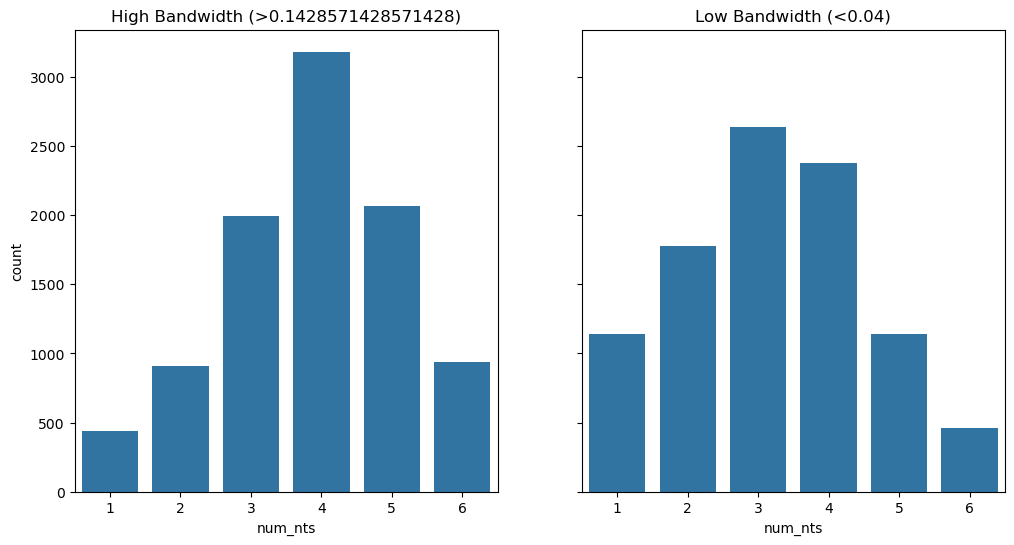

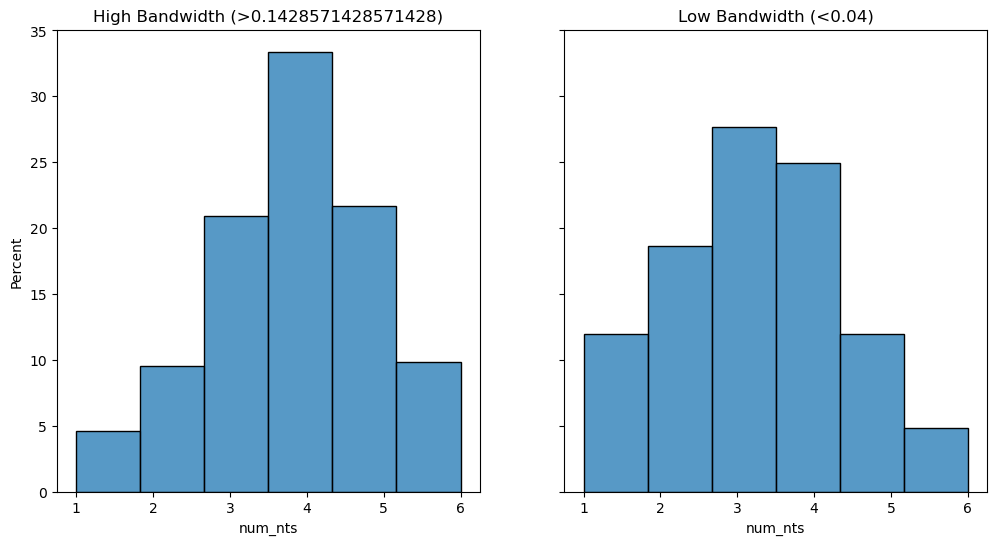

In [51]:
# Absolute Count plots
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.countplot(data=filt_nt_results_df_high, x='num_nts', ax=ax[0])
ax[0].set_title(f'High Bandwidth (>{bandwidth_thresholds[0]})')
sns.countplot(data=filt_nt_results_df_low, x='num_nts', ax=ax[1])
ax[1].set_title(f'Low Bandwidth (<{bandwidth_thresholds[1]})')

# Percentages
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.histplot(data=filt_nt_results_df_high, x='num_nts', ax=ax[0], stat="percent", bins=6)
ax[0].set_title(f'High Bandwidth (>{bandwidth_thresholds[0]})')
sns.histplot(data=filt_nt_results_df_low, x='num_nts', ax=ax[1], stat="percent", bins=6)
ax[1].set_title(f'Low Bandwidth (<{bandwidth_thresholds[1]})')

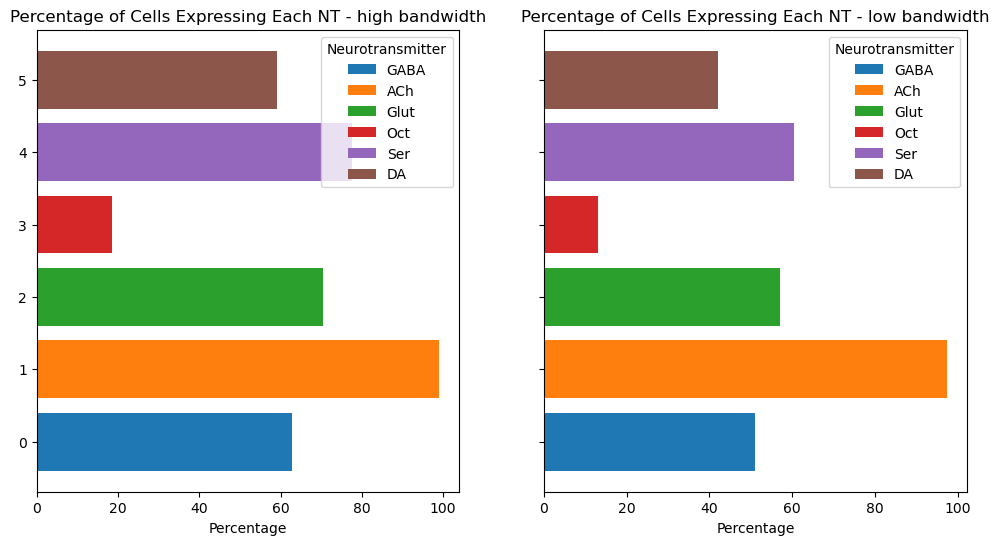

In [151]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
nts = ["GABA", "ACh", "Glut", "Oct", "Ser", "DA"]
# Collate number of each transmitter
for i, nt in enumerate(nts):
    ax[0].barh(i, (filt_nt_results_df_high[nt].sum()/ filt_nt_results_df_high[nt].shape[0]) * 100, label=nt)
ax[0].set_title('Percentage of Cells Expressing Each NT - high bandwidth')
ax[0].set_xlabel('Percentage')
ax[0].legend(title='Neurotransmitter')

for i, nt in enumerate(nts):
    ax[1].barh(i, (filt_nt_results_df_low[nt].sum()/ filt_nt_results_df_high[nt].shape[0]) * 100, label=nt)
ax[1].set_title('Percentage of Cells Expressing Each NT - low bandwidth')
ax[1].set_xlabel('Percentage')
ax[1].legend(title='Neurotransmitter')


,combination_index,num_nts,nts_in_combo,num_neurons
3,4,1,[ACh],1101
0,1,1,[Ser],24
2,3,1,[Glut],10
5,6,1,[GABA],4
1,2,1,[Oct],0
4,5,1,[DA],0


,combination_index,num_nts,nts_in_combo,num_neurons
9,4,2,"[ACh, Glut]",621
7,2,2,"[ACh, Ser]",603
13,8,2,"[GABA, ACh]",383
20,15,2,"[GABA, Glut]",68
6,1,2,"[ACh, DA]",67
14,9,2,"[Glut, Ser]",13
12,7,2,"[ACh, Oct]",7
17,12,2,"[Oct, Ser]",6
19,14,2,"[Ser, DA]",5
15,10,2,"[Glut, DA]",2


,combination_index,num_nts,nts_in_combo,num_neurons
23,3,3,"[GABA, ACh, Glut]",864
24,4,3,"[ACh, Ser, DA]",625
30,10,3,"[ACh, Glut, Ser]",454
36,16,3,"[GABA, ACh, Ser]",331
22,2,3,"[ACh, Glut, DA]",161
39,19,3,"[GABA, ACh, DA]",108
21,1,3,"[ACh, Oct, Ser]",26
27,7,3,"[Glut, Ser, DA]",17
32,12,3,"[GABA, ACh, Oct]",16
35,15,3,"[GABA, Oct, Ser]",10


,combination_index,num_nts,nts_in_combo,num_neurons
53,13,4,"[ACh, Glut, Ser, DA]",685
52,12,4,"[GABA, ACh, Glut, Ser]",617
45,5,4,"[GABA, ACh, Ser, DA]",522
54,14,4,"[GABA, ACh, Glut, DA]",280
51,11,4,"[ACh, Oct, Ser, DA]",64
41,1,4,"[ACh, Glut, Oct, Ser]",60
42,2,4,"[GABA, ACh, Oct, Ser]",41
50,10,4,"[GABA, Oct, Ser, DA]",39
44,4,4,"[GABA, ACh, Glut, Oct]",33
43,3,4,"[GABA, ACh, Oct, DA]",12


,combination_index,num_nts,nts_in_combo,num_neurons
56,1,5,"[GABA, ACh, Glut, Ser, DA]",697
60,5,5,"[GABA, ACh, Glut, Oct, Ser]",213
61,6,5,"[ACh, Glut, Oct, Ser, DA]",100
59,4,5,"[GABA, ACh, Oct, Ser, DA]",91
58,3,5,"[GABA, ACh, Glut, Oct, DA]",24
57,2,5,"[GABA, Glut, Oct, Ser, DA]",13


,combination_index,num_nts,nts_in_combo,num_neurons
62,1,6,"[GABA, ACh, Glut, Oct, Ser, DA]",461


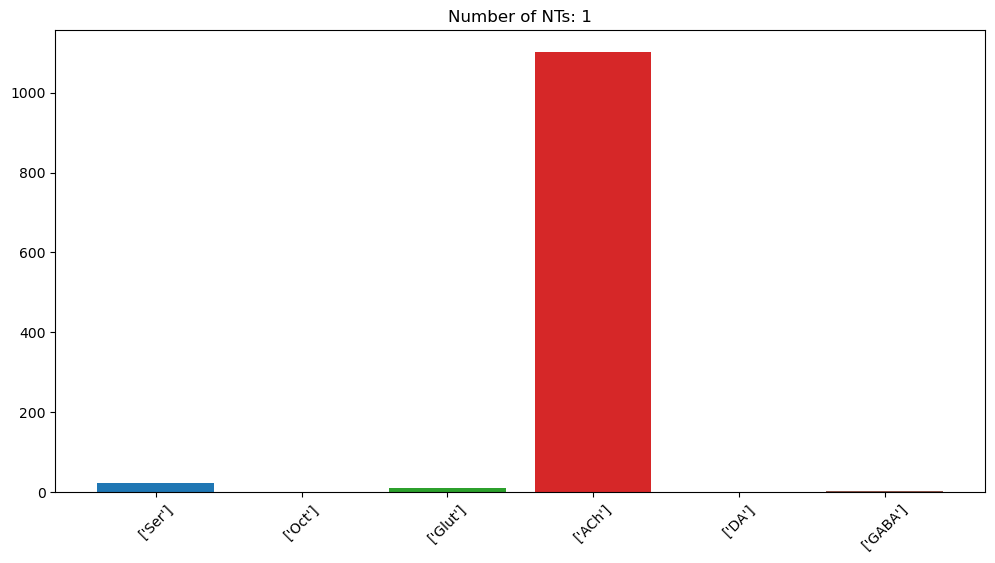

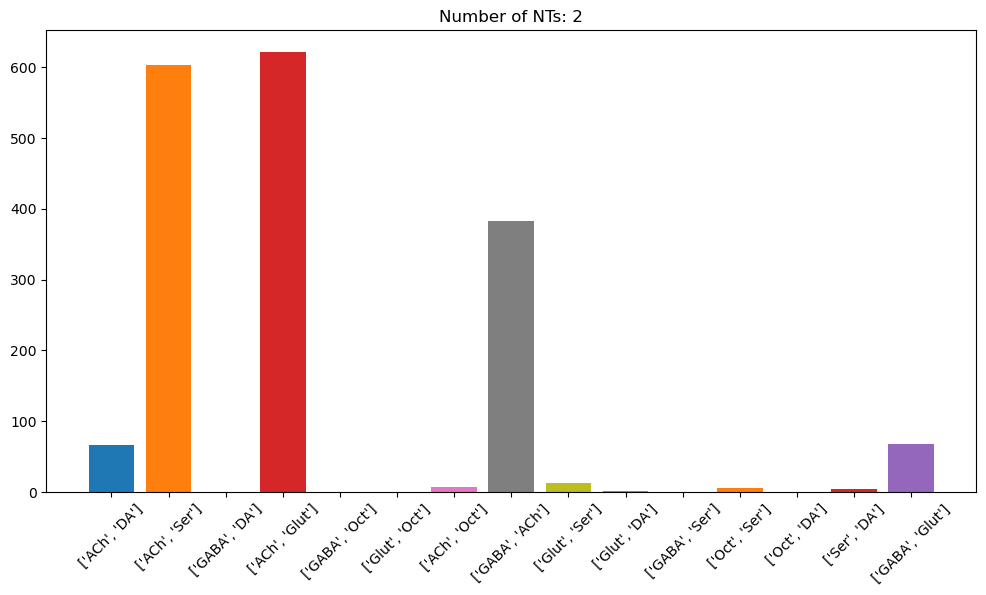

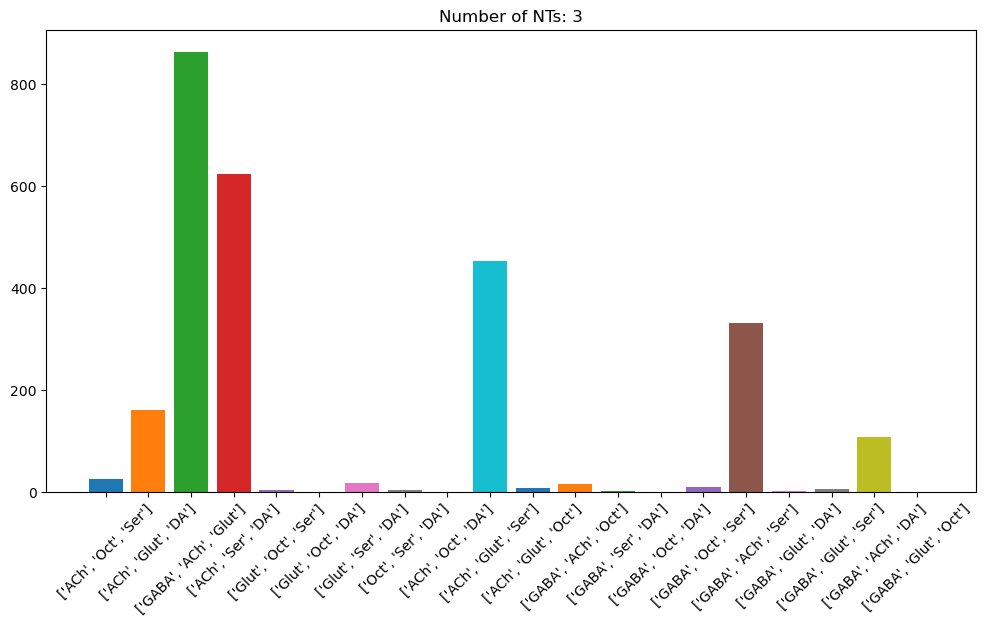

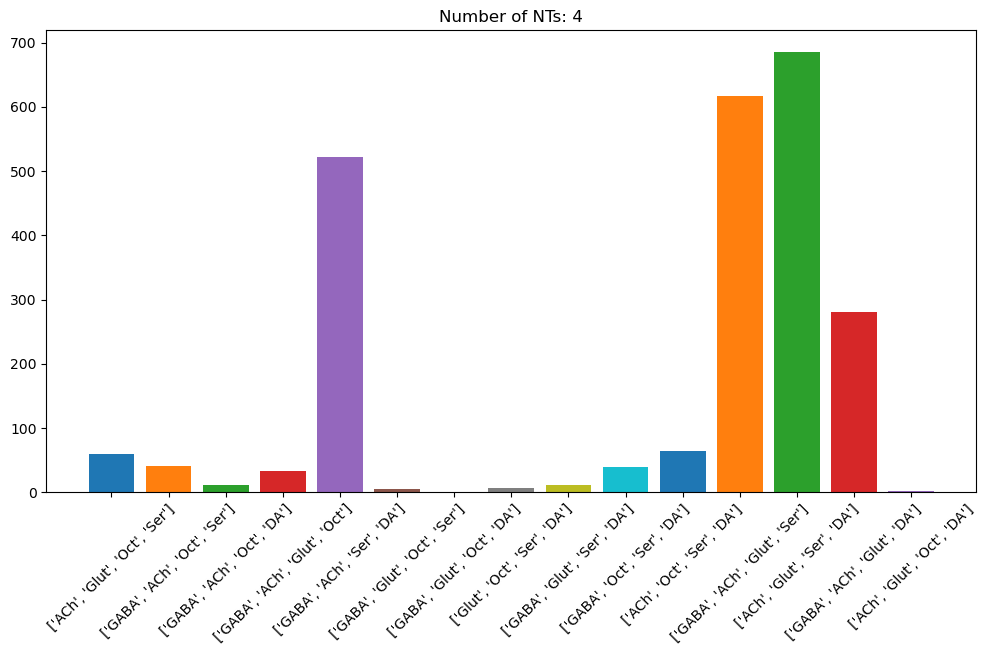

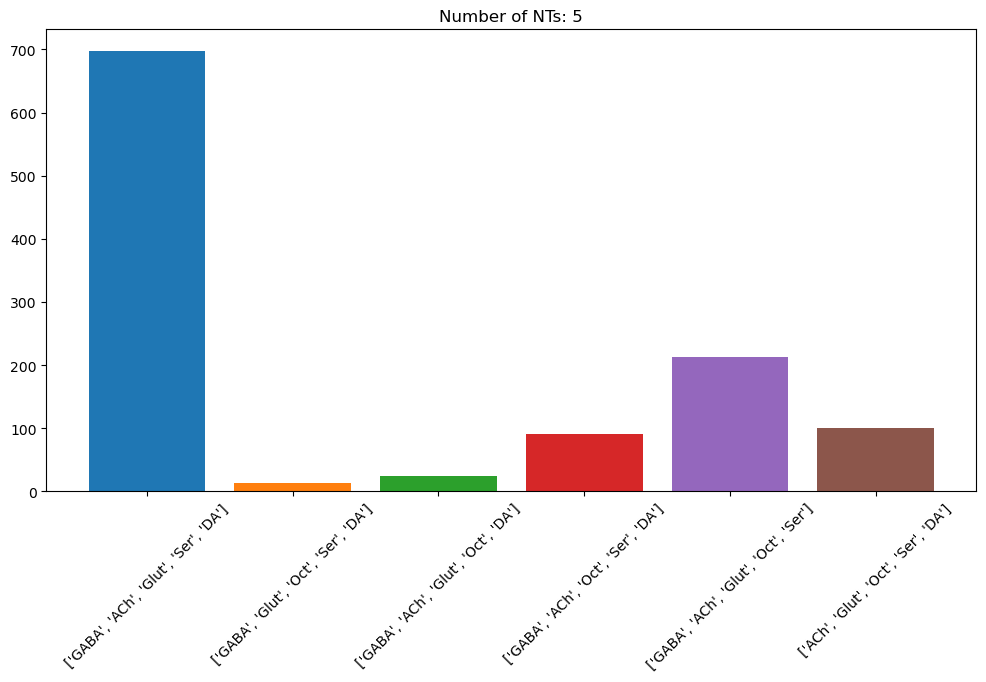

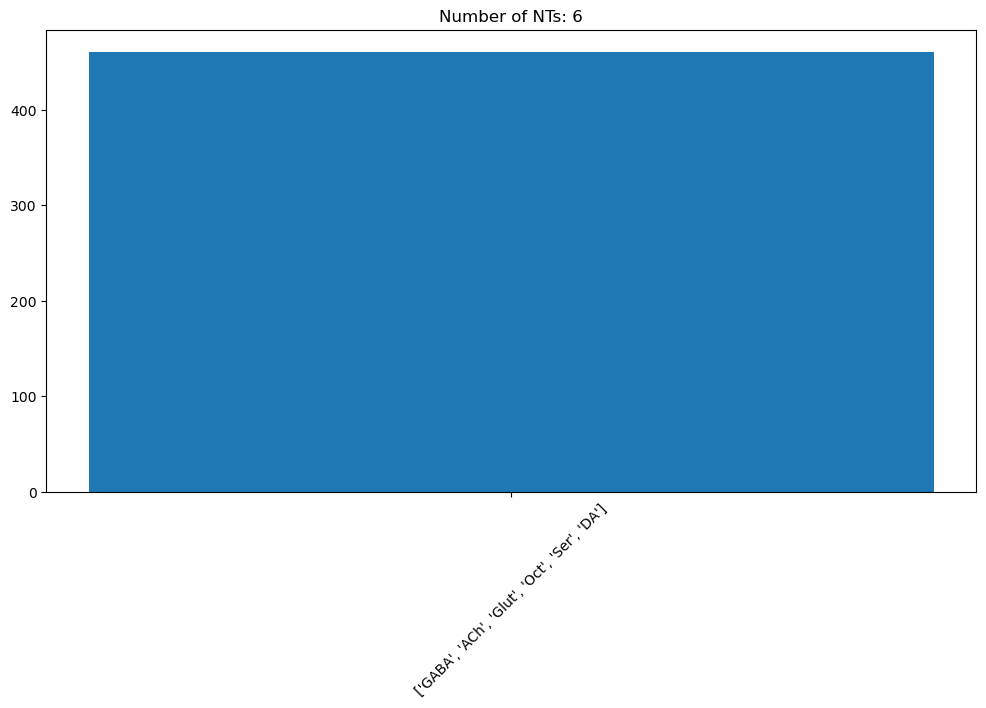

In [103]:
# Now work out which combinations of NTs are most common for the low bandwidth group
nts = ["GABA", "ACh", "Glut", "Oct", "Ser", "DA"]

# Work out all the possible combinations
from itertools import product

# create all boolean combinations (True/False)
combos = list(product([True, False], repeat=len(nts)))
combos_df = pd.DataFrame(combos, columns=nts)
combos_df['num_nts'] = combos_df.sum(axis=1)
combos_df.sort_values('num_nts', inplace=True)
combos_df.reset_index(inplace=True, drop=True)

combination_data = []
# Now count the occurrences of each combination in the low bandwidth filtered DataFrame
for tot_nts in range(1, len(nts) + 1):
    subset_combos_df = combos_df[combos_df['num_nts'] == tot_nts]
    for i in range(subset_combos_df.shape[0]):
        combo = subset_combos_df.iloc[i]
        # Find the nts in the combo
        nts_in_combo = [nt for nt in nts if combo[nt]]
        combo_nt = combo[nts]
        _df = filt_nt_results_df_low[
            (filt_nt_results_df_low[nts[0]] == combo_nt[nts[0]]) &
            (filt_nt_results_df_low[nts[1]] == combo_nt[nts[1]]) &
            (filt_nt_results_df_low[nts[2]] == combo_nt[nts[2]]) &
            (filt_nt_results_df_low[nts[3]] == combo_nt[nts[3]]) &
            (filt_nt_results_df_low[nts[4]] == combo_nt[nts[4]]) &
            (filt_nt_results_df_low[nts[5]] == combo_nt[nts[5]])
             ]

        #Add to key_data dict
        key_data = {
            'combination_index': i + 1,
            'num_nts': tot_nts,
            'nts_in_combo': nts_in_combo,
            'num_neurons': _df.shape[0]
        }
        combination_data.append(key_data)

combination_data_df = pd.DataFrame(combination_data)

for i in range(1, 7):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    _df = combination_data_df[combination_data_df['num_nts'] == i]
    for j, row in _df.iterrows():
        x_name = str(row['nts_in_combo'])
        ax.bar(x_name, row['num_neurons'], label=x_name)
        # Rotate the x-ticks
        ax.tick_params(axis='x', rotation=45)
    ax.set_title(f'Number of NTs: {i}')
    display(_df.sort_values('num_neurons', ascending=False))

## Explore Per Cell Type

In [106]:
classification_system = "cell_type"
cell_type_df = filt_nt_results_df_low[filt_nt_results_df_low['classification_system'] == classification_system]
# Display the filtered DataFrame
display(cell_type_df)

cell_type_list = cell_type_df['cell_type'].unique().tolist()
print(f"There are {len(cell_type_list)} cell types.\nCell types: {cell_type_list}")

,root_id,classification_system,cell_type,num_synapses,min_synapses,softmax_threshold,ratio_threshold,bandwidth_quantile_value,min_synapses_ratio_value,GABA,ACh,Glut,Oct,Ser,DA,Unknown,num_nts,is_co_transmission
1,720575940627828552,cell_type,DNg87,4018,400,0.25,0.16,0.04,0.01,False,True,False,False,True,False,False,2,True
3,720575940628125715,cell_type,DNg87,3551,400,0.25,0.16,0.04,0.01,False,True,False,False,True,True,False,3,True
5,720575940639152361,cell_type,DNg84,6617,400,0.25,0.16,0.04,0.01,True,True,False,False,True,True,False,4,True
7,720575940644473760,cell_type,DNg84,6697,400,0.25,0.16,0.04,0.01,True,True,False,False,True,True,False,4,True
9,720575940621628582,cell_type,DNg85,4796,400,0.25,0.16,0.04,0.01,True,True,False,False,False,True,False,3,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163639,720575940624448956,cell_type,DNg42,1101,400,0.25,0.16,0.04,0.01,True,True,True,False,True,False,False,4,True
163641,720575940627732423,cell_type,DNg45,861,400,0.25,0.16,0.04,0.01,True,True,True,True,True,True,False,6,True
163643,720575940622486644,cell_type,DNg45,754,400,0.25,0.16,0.04,0.01,True,True,True,True,True,True,False,6,True
163645,720575940622037926,cell_type,DNg41,3238,400,0.25,0.16,0.04,0.01,True,True,True,False,True,False,False,4,True


There are 274 cell types.
Cell types: ['DNg87', 'DNg84', 'DNg85', 'DNg83', 'DNg80', 'DNg89', 'DNg86', 'DNg82', 'DNg81', 'DNg88', 'DNx02', 'DNx01', 'DNp57', 'DNp58', 'DNp52', 'DNp56', 'DNp53', 'DNp50', 'DNp54', 'DNp55', 'DNp51', 'DNp59', 'DNc01', 'DNc02', 'DNp72', 'DNp70', 'DNp71', 'DNp73', 'DNa06', 'DNae005', 'DNa14', 'DNae008', 'DNae006', 'DNa01', 'DNa16', 'DNae009', 'DNae001', 'DNae007', 'DNae002', 'DNae010', 'DNa15', 'DNa12', 'DNae004', 'DNae003', 'oviDNa_b', 'oviDNa_a', 'DNae012', 'DNa04', 'DNa13_b', 'DNa05', 'DNae011', 'DNa13_a', 'DNa11', 'DNp36', 'DNp33', 'DNp30', 'DNp38', 'DNp39', 'DNp37', 'DNp35', 'DNp14', 'DNp104', 'DNp12', 'DNp101', 'DNp102', 'DNp103', 'DNp65', 'DNp60', 'DNp69', 'DNp62', 'DNp67', 'DNp63', 'DNp68', 'DNp64', 'DNp66', 'DNg98', 'DNg94', 'DNg91', 'DNg93', 'DNg96', 'DNg92_b', 'DNg90', 'DNg92_a', 'DNg99', 'DNg97', 'DNb08_a', 'DNbe005', 'DNbe002', 'DNb08_b', 'DNb07', 'DNbe003', 'DNbe001', 'DNb09', 'DNbe006', 'DNbe004', 'DNb10', 'DNp41', 'DNp48', 'DNp40', 'DNp46', 'DN

In [107]:
# Sort cell_type_list alphabetically
cell_type_list.sort()
print(cell_type_list)

['DNa01', 'DNa04', 'DNa05', 'DNa06', 'DNa11', 'DNa12', 'DNa13_a', 'DNa13_b', 'DNa14', 'DNa15', 'DNa16', 'DNae001', 'DNae002', 'DNae003', 'DNae004', 'DNae005', 'DNae006', 'DNae007', 'DNae008', 'DNae009', 'DNae010', 'DNae011', 'DNae012', 'DNb07', 'DNb08_a', 'DNb08_b', 'DNb09', 'DNb10', 'DNbe001', 'DNbe002', 'DNbe003', 'DNbe004', 'DNbe005', 'DNbe006', 'DNc01', 'DNc02', 'DNd02', 'DNd03', 'DNd04', 'DNde001', 'DNde002', 'DNde003', 'DNde004', 'DNde005', 'DNde006', 'DNg01_a', 'DNg01_b', 'DNg02_a', 'DNg02_d', 'DNg02_f', 'DNg04', 'DNg05_a', 'DNg06_b', 'DNg06_c', 'DNg07', 'DNg08_a', 'DNg08_b', 'DNg09', 'DNg10', 'DNg100', 'DNg101', 'DNg102_a', 'DNg102_b', 'DNg103', 'DNg104', 'DNg105', 'DNg106', 'DNg107', 'DNg108', 'DNg109', 'DNg11', 'DNg111', 'DNg12_a', 'DNg12_b', 'DNg12_c', 'DNg12_d', 'DNg12_e', 'DNg13', 'DNg14', 'DNg15', 'DNg16', 'DNg17', 'DNg18_a', 'DNg18_b', 'DNg19', 'DNg20', 'DNg21', 'DNg22', 'DNg23', 'DNg24', 'DNg26', 'DNg27', 'DNg28', 'DNg29', 'DNg31', 'DNg32', 'DNg33', 'DNg34', 'DNg35', 'D

In [ ]:
all_cell_type_data = []
for cell_type in cell_type_list:
    cell_type_combos = {}
    _df = cell_type_df[cell_type_df['cell_type'] == cell_type]

    n_nts = []
    nt_present = {nt: 0 for nt in nts}
    for j in range(_df.shape[0]):
        row = _df.iloc[j]
        row_nts = row[nts]

        # which combos_df does row_nts match?
        match_combo = combos_df[combos_df[nts].eq(row_nts).all(axis=1)]
        matching_nts = [nt for nt in nts if row_nts[nt]]

        # Convert matching_nts to a string
        matching_nts_str = ', '.join(matching_nts)

        # Is matching_nts_str already a key in cell_type_combos?
        if matching_nts_str not in cell_type_combos:
            cell_type_combos[matching_nts_str] = 1
        else:
            cell_type_combos[matching_nts_str] += 1

        number_of_nts = len(matching_nts)
        n_nts.append(number_of_nts)

        # Counts for nt_present
        for nt in matching_nts:
            nt_present[nt] += 1

    # convert nt_present into nt_percent
    nt_percent = {nt: (count / _df.shape[0]) * 100 for nt, count in nt_present.items()}
    
    test = {
        "cell_type": cell_type,
        "n_cells": _df.shape[0],
        "mean_n_nts": np.mean(n_nts),
        "std_n_nts": np.std(n_nts),
        "combos": cell_type_combos
    }
    for key in nt_percent:
        test[f"{key}_percent"] = nt_percent[key]
    all_cell_type_data.append(test)

print(all_cell_type_data)

[{'cell_type': 'DNa01', 'n_cells': 2, 'mean_n_nts': np.float64(5.5), 'std_n_nts': np.float64(0.5), 'combos': {'GABA, ACh, Glut, Oct, Ser, DA': 1, 'GABA, ACh, Glut, Ser, DA': 1}, 'GABA_percent': 100.0, 'ACh_percent': 100.0, 'Glut_percent': 100.0, 'Oct_percent': 50.0, 'Ser_percent': 100.0, 'DA_percent': 100.0}, {'cell_type': 'DNa04', 'n_cells': 2, 'mean_n_nts': np.float64(4.5), 'std_n_nts': np.float64(0.5), 'combos': {'GABA, ACh, Glut, Ser, DA': 1, 'GABA, ACh, Glut, DA': 1}, 'GABA_percent': 100.0, 'ACh_percent': 100.0, 'Glut_percent': 100.0, 'Oct_percent': 0.0, 'Ser_percent': 50.0, 'DA_percent': 100.0}, {'cell_type': 'DNa05', 'n_cells': 2, 'mean_n_nts': np.float64(5.5), 'std_n_nts': np.float64(0.5), 'combos': {'GABA, ACh, Glut, Ser, DA': 1, 'GABA, ACh, Glut, Oct, Ser, DA': 1}, 'GABA_percent': 100.0, 'ACh_percent': 100.0, 'Glut_percent': 100.0, 'Oct_percent': 50.0, 'Ser_percent': 100.0, 'DA_percent': 100.0}, {'cell_type': 'DNa06', 'n_cells': 2, 'mean_n_nts': np.float64(2.0), 'std_n_nts': 

In [142]:
cell_type_num_nts_df = pd.DataFrame(all_cell_type_data)
cell_type_num_nts_df.sort_values('cell_type', inplace=True)
cell_type_num_nts_df

,cell_type,n_cells,mean_n_nts,std_n_nts,combos,GABA_percent,ACh_percent,Glut_percent,Oct_percent,Ser_percent,DA_percent
0,DNa01,2,5.5,0.5,"{'GABA, ACh, Glut, Oct, Ser, DA': 1, 'GABA, AC...",100.0,100.0,100.0,50.0,100.0,100.0
1,DNa04,2,4.5,0.5,"{'GABA, ACh, Glut, Ser, DA': 1, 'GABA, ACh, Gl...",100.0,100.0,100.0,0.0,50.0,100.0
2,DNa05,2,5.5,0.5,"{'GABA, ACh, Glut, Ser, DA': 1, 'GABA, ACh, Gl...",100.0,100.0,100.0,50.0,100.0,100.0
3,DNa06,2,2.0,0.0,"{'ACh, Glut': 1, 'GABA, ACh': 1}",50.0,100.0,50.0,0.0,0.0,0.0
4,DNa11,2,3.0,1.0,"{'GABA, ACh, Glut, Ser': 1, 'ACh, Glut': 1}",50.0,100.0,100.0,0.0,50.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
269,OA-VUMx1,1,2.0,0.0,"{'Ser, DA': 1}",0.0,0.0,0.0,0.0,100.0,100.0
270,OA-VUMx2,1,3.0,0.0,"{'ACh, Glut, Ser': 1}",0.0,100.0,100.0,0.0,100.0,0.0
271,OA-VUMx3,1,2.0,0.0,"{'GABA, Glut': 1}",100.0,0.0,100.0,0.0,0.0,0.0
272,oviDNa_a,2,3.5,0.5,"{'ACh, Glut, Ser': 1, 'ACh, Glut, Ser, DA': 1}",0.0,100.0,100.0,0.0,100.0,50.0


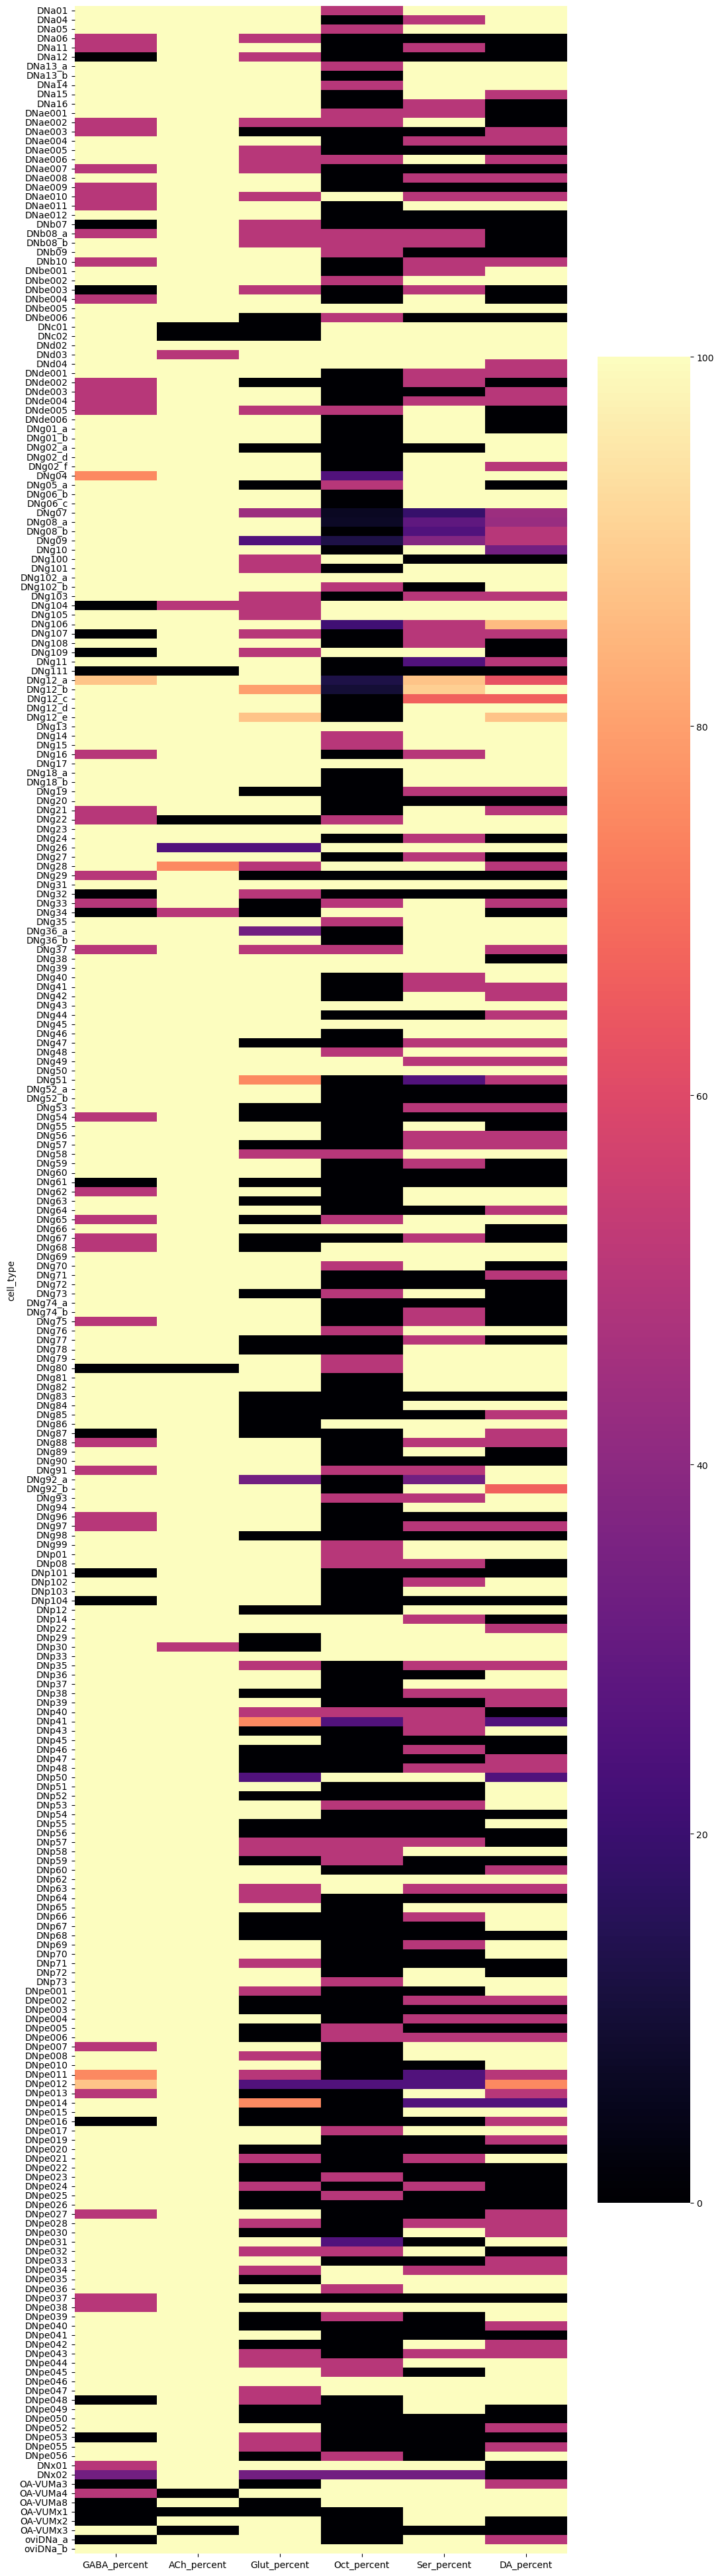

['DNa01', 'DNa04', 'DNa05', 'DNa06', 'DNa11', 'DNa12', 'DNa13_a', 'DNa13_b', 'DNa14', 'DNa15', 'DNa16', 'DNae001', 'DNae002', 'DNae003', 'DNae004', 'DNae005', 'DNae006', 'DNae007', 'DNae008', 'DNae009', 'DNae010', 'DNae011', 'DNae012', 'DNb07', 'DNb08_a', 'DNb08_b', 'DNb09', 'DNb10', 'DNbe001', 'DNbe002', 'DNbe003', 'DNbe004', 'DNbe005', 'DNbe006', 'DNc01', 'DNc02', 'DNd02', 'DNd03', 'DNd04', 'DNde001', 'DNde002', 'DNde003', 'DNde004', 'DNde005', 'DNde006', 'DNg01_a', 'DNg01_b', 'DNg02_a', 'DNg02_d', 'DNg02_f', 'DNg04', 'DNg05_a', 'DNg06_b', 'DNg06_c', 'DNg07', 'DNg08_a', 'DNg08_b', 'DNg09', 'DNg10', 'DNg100', 'DNg101', 'DNg102_a', 'DNg102_b', 'DNg103', 'DNg104', 'DNg105', 'DNg106', 'DNg107', 'DNg108', 'DNg109', 'DNg11', 'DNg111', 'DNg12_a', 'DNg12_b', 'DNg12_c', 'DNg12_d', 'DNg12_e', 'DNg13', 'DNg14', 'DNg15', 'DNg16', 'DNg17', 'DNg18_a', 'DNg18_b', 'DNg19', 'DNg20', 'DNg21', 'DNg22', 'DNg23', 'DNg24', 'DNg26', 'DNg27', 'DNg28', 'DNg29', 'DNg31', 'DNg32', 'DNg33', 'DNg34', 'DNg35', 'D

In [145]:
# Now a heat map for the NT_percent aspect
plt.figure(figsize=(12, 50))
sns.heatmap(
    cell_type_num_nts_df.set_index('cell_type')[['GABA_percent', 'ACh_percent', 'Glut_percent', 'Oct_percent', 'Ser_percent', 'DA_percent']],
    cmap="magma"
)
plt.show()
print(cell_type_num_nts_df['cell_type'].tolist())

In [146]:
cell_type_num_nts_df.describe()

,n_cells,mean_n_nts,std_n_nts,GABA_percent,ACh_percent,Glut_percent,Oct_percent,Ser_percent,DA_percent
count,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000,274.000000
mean,2.364964,3.844247,0.424549,84.519465,95.985401,64.365876,27.201295,57.830857,54.521854
std,1.696261,1.180486,0.411397,30.583081,18.340885,42.517222,38.246234,42.252480,42.609862
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,3.000000,0.000000,100.000000,100.000000,6.250000,0.000000,0.000000,0.000000
50%,2.000000,3.767857,0.500000,100.000000,100.000000,100.000000,0.000000,50.000000,50.000000
75%,2.000000,4.729167,0.500000,100.000000,100.000000,100.000000,50.000000,100.000000,100.000000
max,16.000000,6.000000,2.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [147]:
1/6

0.16666666666666666